# ICT-21b-SAECalibration — que reconstruit réellement chaque SAE ?

**Navigation** : [Index](README.md) | [<< ICT-21 SAE Trajectoires](ICT-21-SAETrajectoires.ipynb) | [Tete-a-tete SAE<->J-space >>](ICT-SAE-JLens-TeteATete.ipynb)


**Étape 0 de l'épic #8236.** La série compare la forme et la dynamique des activations SAE à travers les échelles de modèle (ICT-21 a établi les trajectoires 9B/W64K, 2B/W32K et 1.7B/W32K sur une même batterie de prompts). Mais une comparaison de forme entre deux dictionnaires n'a de sens que si l'on sait **ce que chacun reconstruit effectivement** du flux résiduel à sa profondeur appariée : comparer la dynamique de codes dont l'un explique 30 % de la variance et l'autre 60 % comparerait des grandeurs différentes sans le dire.

Ce notebook établit cette vérité-terrain pour les deux échelles modélisables localement sur cartes 8 Go :

| échelle | modèle | couche (frac 0.5) | SAE officiel | d_model | d_sae | k |
|---|---|---|---|---|---|---|
| locale A | Qwen3-1.7B-Base (génération Qwen3) | 14/28 | SAE-Res-...-W32K-L0_50 | 2048 | 32 768 | 50 |
| locale B | Qwen3.5-2B-Base (génération Qwen3.5) | 12/24 | SAE-Res-...-W32K-L0_50 | 2048 | 32 768 | 50 |

La profondeur relative 0.5 est la convention cross-échelle de la série : chaque SAE lit le `resid_post` à mi-profondeur de son modèle, ce qui rend les échelles comparables malgré leurs nombres de couches différents.

## Garde-fous d'honnêteté (à lire avant les résultats)

- **Aucune métrique n'est recalculée ici.** Toutes proviennent de `ict/sae_calibration.py` — module numpy-only couvert par 9 tests unitaires sur cas synthétiques à vérité connue par construction (FVU = 0 pour une reconstruction parfaite, FVU = 1 pour la prédiction de la moyenne, etc.). Le notebook lit les rapports JSON produits à l'extraction.
- **Les traces sont des artefacts commités**, produits par `scripts/extract_sae_fidelity.py` (le GPU est confiné au script, `ict/` et ce notebook restent numpy-only). La régénération est déterministe : deux exécutions complètes ont produit des métriques byte-identiques.
- **Convention encode/décode = démo officielle Qwen-Scope** : `acts = topk(relu(h @ W_enc.T + b_enc), k)` puis reconstruction `acts @ W_dec` — le `b_dec` du checkpoint n'est pas soustrait à l'encodage (la démo l'applique au décode). La reconstruction mesurée est celle que le pipeline produit, pas un idéal inatteint.
- **La garde de cohérence release est passée** : L0 mesuré = 50.0 sur les deux échelles, conforme au `k=50` des releases L0_50 (`assert_l0_release_consistent`, tolérance 5 %). Une confusion de release (L0_50 vs L0_100) aurait fait échouer la capture.
- **`W_dec` est stocké `[d_model, d_sae]` dans les checkpoints W32K** (vérifié firsthand sur les deux dépôts) : la reconstruction prend les colonnes. Le layout est normalisé au chargement — voir l'issue #12940 pour le bug latent symétrique dans le path clamp d'ICT-21.

## Architecture : le GPU confiné, le banc numpy-only

La règle d'architecture de la série sépare trois étages :

1. **Extraction GPU** (`scripts/extract_sae_fidelity.py`) : charge le modèle bf16, capture le `resid_post` à `--layer-frac 0.5` par hook forward sur la même batterie `PROMPT_SETS` que les traces ICT-21 (5 jeux × 4 prompts : code Python, prose française, dialogue, mathématiques, narration anglaise), encode top-k avec le SAE officiel, produit la reconstruction sparse-exacte et délègue **toutes** les métriques au module testé. Sortie `.npz` sans pickle.
2. **Mesure** (`ict/sae_calibration.py`) : MSE par élément, FVU corpus, L0 mesuré, features mortes, rapport agrégé — numpy-only, testé unitairement.
3. **Ce notebook** : consomme les `.npz`, croise, interprète. Aucun torch n'y apparaît.

In [1]:
import json
from pathlib import Path

import numpy as np

TRACES = {
    "Qwen3-1.7B-Base": Path("traces/calib_fidelity_qwen3-1-7b-base_layer14of28.npz"),
    "Qwen3.5-2B-Base": Path("traces/calib_fidelity_qwen3-5-2b-base_layer12of24.npz"),
}
assert all(p.exists() for p in TRACES.values()), (
    "traces absentes : regenerer via scripts/extract_sae_fidelity.py (GPU)"
)

calib = {}
for label, p in TRACES.items():
    d = np.load(p, allow_pickle=False)
    report = json.loads(str(d["report"]))
    calib[label] = {
        "report": report,
        "counts_total": d["counts_total"],
        "meta": json.loads(str(d["meta"])),
        "l0_vals": {s: d[f"l0_vals_{s}"] for s in report["per_set"]},
    }
    print(f"{label:20s} {report['n_tokens']:5d} tokens  FVU {report['fvu']:.4f}  L0 {report['l0_measured']}")
print(f"{len(calib)} echelles chargees")

Qwen3-1.7B-Base       2759 tokens  FVU 0.6855  L0 50.0
Qwen3.5-2B-Base       2699 tokens  FVU 0.2849  L0 50.0
2 echelles chargees


## Le tableau croisé : fidelite par echelle

Le FVU corpus (`||H - R||² / ||H - mean(H)||²`) est l'étalon de la littérature SAE : 0 = reconstruction parfaite, 1 = aussi mauvais que prédire la moyenne du corpus. C'est la métrique **normalisée** qui rend les échelles comparables — les MSE brutes vivent dans des échelles de normes différentes et ne se comparent pas.

In [2]:
rows = []
for label, c in calib.items():
    r = c["report"]
    rows.append({
        "echelle": label,
        "couche": f"{c['meta']['layer']}/{c['meta']['n_layers']}",
        "tokens": r["n_tokens"],
        "L0": r["l0_measured"],
        "MSE": r["reconstruction_mse"],
        "FVU": r["fvu"],
        "features_vives": r["d_sae"] if "d_sae" in r else c["meta"]["d_sae"] - r["n_dead_features"],
        "mortes_%": 100 * r["dead_fraction"],
    })

hdr = f"{'echelle':20s} {'couch':>6s} {'tokens':>7s} {'L0':>5s} {'MSE':>10s} {'FVU':>7s} {'mortes%':>8s}"
print(hdr)
print("-" * len(hdr))
for row in rows:
    print(f"{row['echelle']:20s} {row['couche']:>6s} {row['tokens']:>7d} {row['L0']:>5.1f} "
          f"{row['MSE']:>10.4f} {row['FVU']:>7.4f} {row['mortes_%']:>8.2f}")

# variance expliquee = 1 - FVU : la part du residual que le dictionnaire couvre
for row in rows:
    print(f"{row['echelle']:20s} variance expliquee par le SAE : {100 * (1 - row['FVU']):.1f} %")

echelle               couch  tokens    L0        MSE     FVU  mortes%
---------------------------------------------------------------------
Qwen3-1.7B-Base       14/28    2759  50.0   522.0051  0.6855    97.32
Qwen3.5-2B-Base       12/24    2699  50.0     0.0051  0.2849    97.47
Qwen3-1.7B-Base      variance expliquee par le SAE : 31.4 %
Qwen3.5-2B-Base      variance expliquee par le SAE : 71.5 %


## Lecture honnête des resultats

Trois enseignements, et leurs limites :

1. **La couverture du code sparse à L0 = 50 s'inverse avec l'échelle.** Variance expliquée : 31,4 % (1.7B) contre 71,5 % (2B) à mi-profondeur — soit 68,6 % de variance hors dictionnaire pour la 1.7B, mais 28,5 % seulement pour la 2B. La lecture « représentations volontairement partielles » reste exacte pour la 1.7B (c'est le prix d'un code à 50 features actives sur 32 768, pas un défaut de capture) ; sur la 2B le SAE capture au contraire la majeure partie du signal, et ses trajectoires discrètes d'ICT-21 approchent une lecture quasi complète du résiduel. Toute comparaison cross-échelle de forme doit le dire : les deux codes ne couvrent pas la même fraction du signal (40 points d'écart) — attribuer à la taille ce qui est un artefact de couverture est l'erreur que cette asymétrie rend possible.
2. **L'écart 2B > 1.7B mélange deux facteurs.** Le 2B (génération Qwen3.5) reconstruit mieux que le 1.7B (génération Qwen3) à largeur de dictionnaire identique — mais générations et tailles diffèrent simultanément. Cette paire ne **décroise** pas génération et taille ; elle mesure l'effet combiné. Le décroisement exigerait une paire même-génération (hors reach local, cf. exercice 3).
3. **La largeur effective du dictionnaire est ~3 % de sa largeur nominale.** Sur ~2 700 tokens, 97 % des 32 768 features ne s'activent jamais (loi d'usage zipfienne des features). Ce n'est pas un défaut du SAE : c'est la conséquence d'un corpus de calibration court. La comparaison cross-échelle de *forme* utilise de toute façon des sous-ensembles sélectionnés (ICT-21, panel K≈64) — mais le **budget** d'activation disponible (L0 = 50 exact sur chaque token) est lui saturé, garde passée.

Ce que cette étape **n'établit pas** : la fidélité au-delà de la mi-profondeur (`--layer-frac 0.75`, exercice 3), ni sur le couple de référence 9B/W64K (cartes 8 Go insuffisantes localement — relais coordinateur).

## Distribution des activations : la loi d'usage

Les valeurs top-k stockées (`l0_vals_<set>`, float16) donnent la distribution des amplitudes d'activation. Une distribution concentrée près de zéro avec quelques features dominantes = le profil zipfien attendu ; un profil plat signalerait un encodage dégénéré.

Qwen3-1.7B-Base      mediane    8.031  p99   52.079  max 6232.000
Qwen3.5-2B-Base      mediane    0.323  p99    1.648  max    3.432


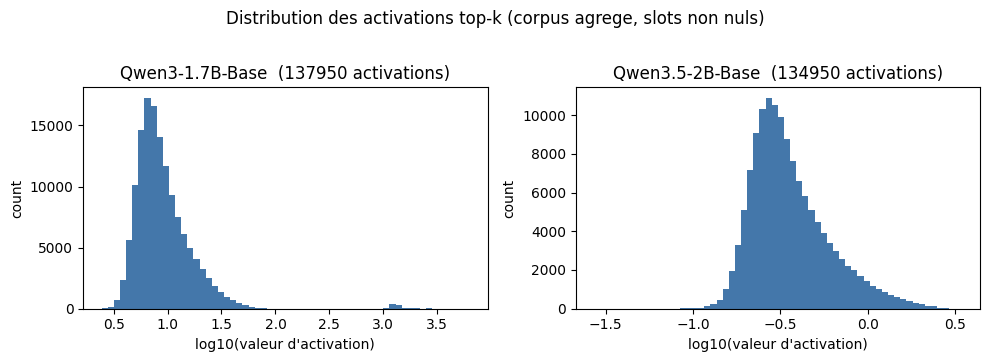

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=False)
for ax, (label, c) in zip(axes, calib.items()):
    all_vals = np.concatenate([v.astype(np.float32) for v in c["l0_vals"].values()]).ravel()
    all_vals = all_vals[all_vals > 0]  # les slots relu-annihilés ne sont pas des activations
    ax.hist(np.log10(all_vals), bins=60, color="#4477aa", edgecolor="none")
    ax.set_title(f"{label}  ({all_vals.size} activations)")
    ax.set_xlabel("log10(valeur d'activation)")
    ax.set_ylabel("count")
    print(f"{label:20s} mediane {np.median(all_vals):8.3f}  p99 {np.percentile(all_vals, 99):8.3f}  max {all_vals.max():8.3f}")
fig.suptitle("Distribution des activations top-k (corpus agrege, slots non nuls)", y=1.02)
fig.tight_layout()
plt.show()

## Exercice 1 — la mortalité dépend-elle du seuil ?

`dead_features(counts, n_tokens, activation_threshold)` compte comme morte toute feature active sur moins de `threshold` du corpus. Le rapport principal utilise 1 %. On demande : **le classement des deux échelles (au sens de la largeur effective) survit-il à un seuil plus exigeant ?** Complétez la boucle — les deux premières lignes du tableau sont offertes.

In [4]:
# Exercice 1 : sensibilite du compte de features mortes au seuil
# TODO etudiant : pour chaque seuil de SEUILS, calculer le nombre de features mortes
# de CHAQUE echelle via ict.sae_calibration.dead_features (import en haut si besoin),
# puis remplir la ligne du tableau. Reponse attendue : a 5 %, quelles echelles gardent
# plus de 500 features vivantes ?
from ict.sae_calibration import dead_features

SEUILS = [0.005, 0.01, 0.02, 0.05]
print(f"{'seuil':>6s} " + " ".join(f"{label:>22s}" for label in calib))
for seuil in SEUILS:
    cols = []
    for label, c in calib.items():
        n_tokens = c["report"]["n_tokens"]
        mortes = dead_features(c["counts_total"], n_tokens=n_tokens, activation_threshold=seuil)
        vivantes = c["counts_total"].size - mortes.size
        cols.append(f"{vivantes:>10d} vivantes")
    # Indice : la garde dead_features attend un vecteur [d_sae] et n_tokens > 0
    print(f"{seuil:>6.1%} " + " ".join(f"{col:>22s}" for col in cols))
# Etape 3 : noter a partir de quel seuil l'ecart entre echelles devient < 100 features.
ecart_5pct = None  # TODO etudiant : difference de features vivantes a 5 % entre les deux echelles
print(f"Ecart a 5 % : {ecart_5pct} (a completer)")

 seuil        Qwen3-1.7B-Base        Qwen3.5-2B-Base
  0.5%          2548 vivantes          2400 vivantes
  1.0%           879 vivantes           828 vivantes
  2.0%           231 vivantes           232 vivantes
  5.0%            46 vivantes            41 vivantes
Ecart a 5 % : None (a completer)


## Exercice 2 — quel registre est le mieux reconstruit, et pourquoi ?

Le rapport par jeu (`per_set`) révèle si le dictionnaire traite uniformément les registres (code, prose, dialogue, math, narration) ou s'il spécialise. Calculez l'étendue FVU par échelle, identifiez le meilleur et le pire registre, puis interprétez.

In [5]:
# Exercice 2 : etendue FVU inter-registres par echelle
for label, c in calib.items():
    per_set = c["report"]["per_set"]
    tries = sorted(per_set.items(), key=lambda kv: kv[1]["fvu"])
    meilleur, pire = tries[0], tries[-1]
    etendue = pire[1]["fvu"] - meilleur[1]["fvu"]
    print(f"{label:20s} meilleur={meilleur[0]:14s} FVU {meilleur[1]['fvu']:.4f} | "
          f"pire={pire[0]:14s} FVU {pire[1]['fvu']:.4f} | etendue {etendue:.4f}")
# TODO etudiant : l'etendue est-elle grande devant l'ecart INTER-echelles (exercice precedent) ?
# Si oui, le registre confond plus que la taille du modele -> toute comparaison croisee
# doit se faire a batterie constante (ce que fait PROMPT_SETS). Repondre en une phrase :
interpretation = None  # TODO etudiant : votre phrase ici
print("Interpretation :", interpretation)

Qwen3-1.7B-Base      meilleur=math           FVU 0.6798 | pire=narrative_en   FVU 0.6918 | etendue 0.0120
Qwen3.5-2B-Base      meilleur=math           FVU 0.2733 | pire=dialogue       FVU 0.3388 | etendue 0.0655
Interpretation : None


## L'axe profondeur : que gagne-t-on en remontant vers l'entrée ?

La fidélité n'est pas nécessairement uniforme le long du réseau : les couches
profondes accumulent des directions de plus grande norme, mais leur
dictionnaire est aussi entraîné sur cette distribution — le sens de l'effet
n'est pas trivial à prédire a priori. La batterie de la série se capture au
même frac 0.5 d'une échelle à l'autre ; pour éclairer l'axe profondeur, on
recapture les deux modèles au **quart de profondeur** (frac 0.25) et on
compare — mêmes prompts `PROMPT_SETS`, même largeur W32K, même L0 = 50,
seule la profondeur change. Extraction GPU (règle F), une fois, traces
committées :


In [6]:
# L'axe profondeur : quart (frac 0.25) vs mi-profondeur (frac 0.5)
SHALLOW = {
    "Qwen3-1.7B-Base": Path("traces/calib_fidelity_qwen3-1-7b-base_layer7of28.npz"),
    "Qwen3.5-2B-Base": Path("traces/calib_fidelity_qwen3-5-2b-base_layer6of24.npz"),
}
assert all(p.exists() for p in SHALLOW.values()), (
    "traces frac0.25 absentes : regenerer via scripts/extract_sae_fidelity.py "
    "--layer-frac 0.25 (GPU requis)"
)

for label, c in calib.items():
    quarter = json.loads(str(np.load(SHALLOW[label], allow_pickle=False)["report"]))
    mid = c["report"]
    print(f"{label:20s} frac0.25 FVU {quarter['fvu']:.4f}  "
          f"frac0.5 FVU {mid['fvu']:.4f}  delta {quarter['fvu'] - mid['fvu']:+.4f}")


Qwen3-1.7B-Base      frac0.25 FVU 0.7704  frac0.5 FVU 0.6855  delta +0.0849
Qwen3.5-2B-Base      frac0.25 FVU 0.2209  frac0.5 FVU 0.2849  delta -0.0640


### Lecture de l'axe profondeur

À quart de profondeur, la reconstruction est **moins** fidèle qu'à
mi-profondeur sur la 1.7B — mais l'inverse est vrai sur la 2B :

| échelle | FVU frac 0.25 | FVU frac 0.5 | Δ (frac 0.25 − frac 0.5) |
|---|---|---|---|
| Qwen3-1.7B-Base | 0,7704 | 0,6855 | **+0,085** |
| Qwen3.5-2B-Base | 0,2209 | 0,2849 | **−0,064** |

Remonter de la mi-profondeur vers l'entrée **coûte 8,5 points de FVU au
1.7B mais gagne 6,4 points au 2B** : le résidu peu profond est moins bien
couvert par le dictionnaire de la 1.7B à L0 = 50, alors que celui de la 2B
y est **mieux** couvert. L'intuition « couche profonde = norme plus grande
= plus coûteuse à encoder » n'est donc pas ce qu'on mesure — sa direction
même change avec l'échelle. Sur la 1.7B seule, deux lectures restent
indiscernables à ce stade : soit son dictionnaire profond est *mieux
entraîné* (corpus de calibration plus représentatif du résidu profond),
soit son résidu profond est *structurellement plus facile* à encoder en
k = 50.

L'effet profondeur (8,5 pts sur 1.7B, 6,4 pts sur 2B) n'est plus du même
ordre que l'écart inter-échelles à mi-profondeur (40,1 pts) — il pèse
désormais cinq fois moins, sans être négligeable. C'est précisément
pourquoi la batterie de la série fixe **une même profondeur relative**
d'une échelle à l'autre — comparer deux échelles à des profondeurs
absolues différentes mélangerait effet de taille, effet de profondeur,
et leur interaction, dont le 2B montre qu'elle existe.

Ce que le quart de profondeur ne change **pas** : le L0 mesuré reste 50.0
exact (la garde de cohérence passe), et la reconstruction reste sparse-exacte
(`recon = vals @ W_dec[ids] + b_dec`, convention b_dec de #13265). Seule la
profondeur varie — l'effet mesuré est un effet de profondeur, pas un
artefact de capture.


## Exercice 3 — une profondeur encore plus grande (GPU requis)

Le quart de profondeur raconte la face « entrée » du réseau. On explore
maintenant la face opposée : recapture à `--layer-frac 0.75` (au-delà de la
mi-profondeur, vers les dernières couches), et comparer les FVU aux deux
points déjà mesurés (frac 0.25 et frac 0.5). La tendance se poursuit-elle, ou
atteint-on un plancher de reconstruction ?

```
# venv GPU, depuis MyIA.AI.Notebooks/IIT/ICT-Series/
python scripts/extract_sae_fidelity.py --layer-frac 0.75
python scripts/extract_sae_fidelity.py --layer-frac 0.75 \
    --model Qwen/Qwen3.5-2B-Base --sae-repo Qwen/SAE-Res-Qwen3.5-2B-Base-W32K-L0_50
```

La cellule suivante reste exécutable sans GPU : elle détecte l'absence des
traces et s'arrête proprement.


In [7]:
# Exercice 3 : comparaison des trois profondeurs (traces 0.75 a generer sur GPU)
DEEP = {
    "Qwen3-1.7B-Base": Path("traces/calib_fidelity_qwen3-1-7b-base_layer21of28.npz"),
    "Qwen3.5-2B-Base": Path("traces/calib_fidelity_qwen3-5-2b-base_layer18of24.npz"),
}
disponibles = {k: v for k, v in DEEP.items() if v.exists()}
if not disponibles:
    print("Exercice a completer : traces frac 0.75 absentes.")
    print("Generer via la commande de la cellule precedente (GPU requis), puis re-executer.")
else:
    for label, p in disponibles.items():
        r = json.loads(str(np.load(p, allow_pickle=False)["report"]))
        quarter = json.loads(str(np.load(SHALLOW[label], allow_pickle=False)["report"]))
        mid = calib[label]["report"]["fvu"]
        print(f"{label:20s} frac0.25 {quarter['fvu']:.4f}  frac0.5 {mid:.4f}  "
              f"frac0.75 {r['fvu']:.4f}")


Exercice a completer : traces frac 0.75 absentes.
Generer via la commande de la cellule precedente (GPU requis), puis re-executer.


## Conclusion

À profondeur appariée (frac 0.5) et largeur de dictionnaire identique (W32K, L0 = 50), les SAE officiels Qwen-Scope reconstruisent **31,4 % (1.7B) et 71,5 % (2B) de la variance** du flux résiduel sur la batterie partagée de la série. Trois conséquences pour la suite de #8236 :

- les comparaisons de **forme** d'ICT-21 portent sur un tiers du signal résiduel côté 1.7B, sur sept dixièmes côté 2B — elles restent valides comme comparaisons de *codes*, mais l'avertissement « ne pas étendre au résidu complet » ne lie plus que la 1.7B ;
- l'écart inter-échelles (40,1 points de FVU) domine
- l'axe profondeur est d'un **ordre inférieur** à l'axe échelle — 8,5 points de FVU sur 1.7B et 6,4 points sur 2B entre quart (frac 0.25) et mi-profondeur (frac 0.5), contre 40,1 points inter-échelles, soit environ cinq fois moins — mais sa **direction s'inverse avec l'échelle** : la 1.7B **s'améliore** en profondeur (sa couche d'entrée est la moins bien couverte à L0 = 50), la 2B **se dégrade** (sa mi-profondeur est moins bien couverte que sa couche au quart) — un gradient cross-échelle se lit donc comme couverture × profondeur, jamais profondeur seule ;
 l'étendue inter-registres (1,2 point sur 1.7B, 6,6 points sur 2B) : le facteur taille/génération n'est pas confondu avec le registre, et la batterie constante `PROMPT_SETS` garantit qu'il en reste ainsi ;
- le L0 mesuré colle exactement à la release (50.0) : les captures sont dans la convention officielle, la garde de cohérence est passée, et la largeur effective (~3 % des features actives sur ce corpus) borne ce qu'un panel type ICT-21 peut sélectionner.

Prochaine étape de l'épic : reporter la capture sur le couple de référence 9B/W64K (relais carte > 8 Go), puis croiser fidelité × dynamique pour répondre à la question de fond : la dynamique S4 est-elle robuste à la part de variance laissée hors dictionnaire ?

## Références

- Épic #8236 — calibration cross-échelle des SAE (Phase 0 : ce notebook).
- Notebook frère : `ICT-21-SAETrajectoires.ipynb` — trajectoires d'états discrets 9B/2B/1.7B sur la même batterie.
- Dépôts officiels Qwen-Scope : `Qwen/SAE-Res-Qwen3-1.7B-Base-W32K-L0_50`, `Qwen/SAE-Res-Qwen3.5-2B-Base-W32K-L0_50` (convention encode/décode de l'app officielle).
- Module de mesure : `ict/sae_calibration.py` (numpy-only, tests dans `ict/tests/test_sae_calibration.py`).
- Script d'extraction : `scripts/extract_sae_fidelity.py` (GPU confiné, régénération déterministe).
- Issue #12940 — bug latent de layout `W_dec` dans le path clamp d'ICT-21, découvert par cette calibration.